# 01. Lexical Feature Engineering

**Goal:** Explore the target distribution and engineer our first set of features based purely on raw word overlap. In Pairwise Text classification, we do NOT feed the raw text to the model! We feed *distance metrics* between the two texts.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('../../../shared')
from text_utils import clean_text_basic

## 1. Load Data

In [2]:
df = pd.read_csv('../data/raw/dataset.csv')
df['question1'] = df['question1'].fillna('')
df['question2'] = df['question2'].fillna('')
print(df.head())
print(f'Total pairs: {len(df)}')

                                           question1  \
0  What would Rhaegar and Jon have thought of eac...   
1  What are the pros and cons of being a driver f...   
2                             Who first started NGO?   
3  Where can I get india vs spain davis cup 2016 ...   
4  How can an unmarried couple book a hotel room ...   

                                           question2  is_duplicate  
0  What is the amount of torque a 2000 Jeep Chero...             0  
1  What are the pros and cons of being a driver f...             0  
2                  What should I do to start an NGO?             0  
3  How can I get tickets for the India Spain Davi...             1  
4  What hotel in Khowai would be safe for unmarri...             0  
Total pairs: 100000


## 2. Target Distribution

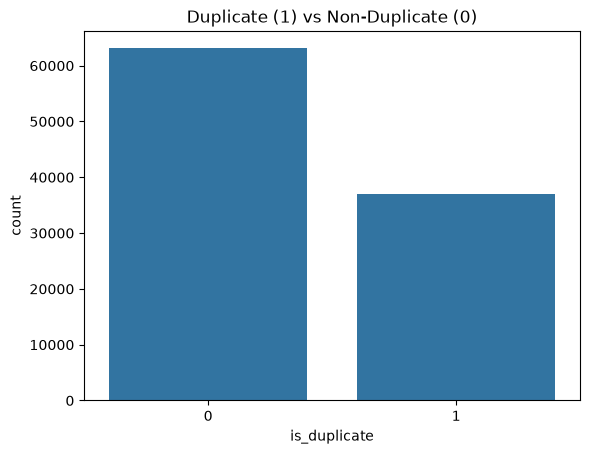

In [3]:
sns.countplot(x='is_duplicate', data=df)
plt.title('Duplicate (1) vs Non-Duplicate (0)')
plt.show()

## 3. Basic Cleaning

In [4]:
df['q1_clean'] = df['question1'].apply(clean_text_basic)
df['q2_clean'] = df['question2'].apply(clean_text_basic)

> **📌 Decision Note — Why Feature Engineering Approach?**
>
> **Chosen approach:** Calculating distance metrics (e.g., Jaccard Similarity, Word Overlap)
>
> **Why this works:** Creates dense numerical features that tabular models (like Random Forest) can easily split on.
>
> **Alternatives we could have used:**
> | Option | Pros | Cons |
> |--------|------|------|
> | Raw TF-IDF Matrix Concatenation | No engineering required | Concatenating two 50k sparse vectors creates a massive 100k vector that is heavily prone to overfitting and extremely slow to train. |
> | Siamese Neural Networks (Deep Learning) | State of the art | Requires deep learning architectures (LSTMs or Transformers). Not suitable for Classical NLP constraints. |
>
> **Why we chose this over alternatives:** Classical pairwise classification relies almost entirely on human-engineered distance metrics.

## 4. Engineer Jaccard Similarity & Word Overlap

In [5]:
def jaccard_similarity(row):
    w1 = set(str(row['q1_clean']).split())
    w2 = set(str(row['q2_clean']).split())
    if len(w1) == 0 or len(w2) == 0:
        return 0.0
    intersection = len(w1.intersection(w2))
    union = len(w1.union(w2))
    return intersection / union

def word_overlap(row):
    w1 = set(str(row['q1_clean']).split())
    w2 = set(str(row['q2_clean']).split())
    return len(w1.intersection(w2))

df['jaccard_sim'] = df.apply(jaccard_similarity, axis=1)
df['word_overlap'] = df.apply(word_overlap, axis=1)

# Also compute absolute difference in length
df['len_diff'] = abs(df['q1_clean'].str.len() - df['q2_clean'].str.len())
df[['q1_clean', 'q2_clean', 'jaccard_sim', 'word_overlap', 'len_diff']].head()

,q1_clean,q2_clean,jaccard_sim,word_overlap,len_diff
0,what would rhaegar and jon have thought of eac...,what is the amount of torque a jeep cherokee c...,0.105263,2,2
1,what are the pros and cons of being a driver f...,what are the pros and cons of being a driver f...,0.882353,15,5
2,who first started ngo,what should i do to start an ngo,0.090909,1,11
3,where can i get india vs spain davis cup tickets,how can i get tickets for the india spain davi...,0.571429,8,12
4,how can an unmarried couple book a hotel room ...,what hotel in khowai would be safe for unmarri...,0.200000,6,11


In [6]:
df.to_csv('../data/processed/features_part1.csv', index=False)
print('Saved initial features.')

Saved initial features.
